# Week 2 — MLPs, nonlinearity, and what the hidden layer does



In [ ]:
# --- Imports and RNG seeding -------------------------------------------------
# We use PyTorch for the networks (autograd gives us Jacobians for free),
# numpy/matplotlib for plotting, and scikit-learn only for the dataset and
# the linear baseline in Part 1.
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Seed everything that could drift:
#   numpy:  dataset split, grid construction, color permutations
#   torch:  network initialization, any stochastic training step
np.random.seed(0)
torch.manual_seed(0)

%matplotlib inline

## Data

Two interleaved half-moons, 400 points, 75/25 split. The curvature between
the two half-moons is what makes this impossible for a linear classifier —
and exactly what the MLP's piecewise-affine structure will carve up.


train: (300, 2), test: (100, 2)
class balance (train): 147 ones, 153 zeros


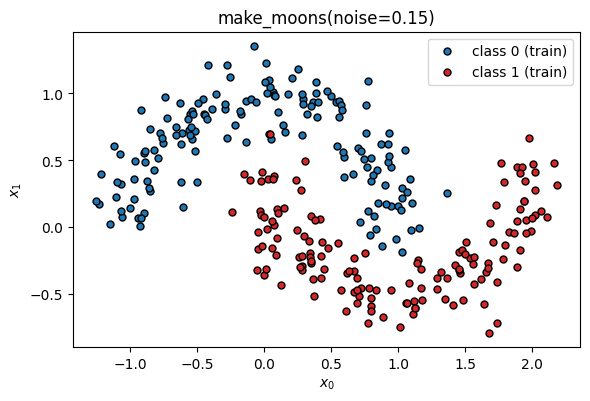

In [ ]:
# 400 samples, mild Gaussian noise (0.15) to prevent trivial separation,
# fixed random_state so every run of this notebook sees the same data.
X, y = make_moons(n_samples=400, noise=0.15, random_state=0)

# 75/25 train/test split, also with fixed seed so accuracy numbers are
# reproducible across runs.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

# Torch tensors for the MLP. We keep numpy copies for plotting and for
# anything that doesn't need gradient tracking.
Xtr = torch.tensor(X_tr, dtype=torch.float32)
ytr = torch.tensor(y_tr, dtype=torch.float32)
Xte = torch.tensor(X_te, dtype=torch.float32)
yte = torch.tensor(y_te, dtype=torch.float32)

print(f"train: {X_tr.shape}, test: {X_te.shape}")
print(f"class balance (train): {int(y_tr.sum())} ones, {len(y_tr) - int(y_tr.sum())} zeros")

# Visualize the raw dataset so the rest of the session has a mental reference.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1],
           c='tab:blue', edgecolor='k', s=25, label='class 0 (train)')
ax.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1],
           c='tab:red',  edgecolor='k', s=25, label='class 1 (train)')
ax.set_title('make_moons(noise=0.15)')
ax.set_xlabel('$x_0$'); ax.set_ylabel('$x_1$'); ax.legend()
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Part 1 — A linear model can't solve this

Logistic regression models a linear decision boundary $w^\top x + b = 0$.
The two moons are curved, and no single straight line can separate them
without cutting through points of both classes.


Linear model: train acc = 0.8667, test acc = 0.9000


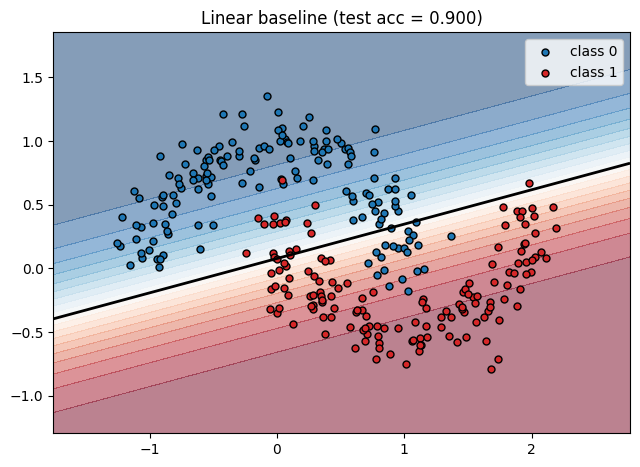

In [ ]:
# sklearn's LogisticRegression is fit with liblinear or lbfgs by default;
# for this small 2D problem it converges in milliseconds. We just want the
# baseline accuracy number and the decision boundary to compare against.
lr_model = LogisticRegression()
lr_model.fit(..., ...)

train_acc_lin = lr_model.score(.., ..)
test_acc_lin  = lr_model.score(.., ..)
print(f"Linear model: train acc = {train_acc_lin:.4f}, test acc = {test_acc_lin:.4f}")

# --- plotting helpers we'll reuse throughout the notebook -------------------
def make_grid(X_ref, pad=0.5, n=400):
    '''Rectangular grid covering the data with a margin. Returns XX, YY (for
    plotting) and G (flattened (N, 2) array for model evaluation).'''
    x0 = np.linspace(X_ref[:, 0].min() - pad, X_ref[:, 0].max() + pad, n)
    x1 = np.linspace(X_ref[:, 1].min() - pad, X_ref[:, 1].max() + pad, n)
    XX, YY = np.meshgrid(x0, x1)
    G = np.stack([XX.ravel(), YY.ravel()], axis=1)
    return XX, YY, G

def plot_points(ax, X, y, **kw):
    '''Scatter the two classes with sensible defaults.'''
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', edgecolor='k',
               s=25, label='class 0', **kw)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:red',  edgecolor='k',
               s=25, label='class 1', **kw)

# Evaluate the classifier on the grid and plot the 0.5-probability contour:
XX, YY, G = make_grid(X)
P = lr_model.predict_proba(G)[:, 1].reshape(XX.shape)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.contourf(XX, YY, P, levels=20, cmap='RdBu_r', alpha=0.5)
ax.contour(XX, YY, P, levels=[0.5], colors='k', linewidths=2)
plot_points(ax, X_tr, y_tr)
ax.set_title(f'Linear baseline (test acc = {test_acc_lin:.3f})')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Part 2 — A small ReLU MLP



In [ ]:
class MLP(nn.Module):
    '''A minimal feed-forward net with ReLU or tanh activations.

    `hidden` is a tuple of hidden layer widths. For example:
        MLP(hidden=(8,))       -> 2 -> 8 -> 1     (one hidden layer)
        MLP(hidden=(6, 6))     -> 2 -> 6 -> 6 -> 1 (two hidden layers)

    The forward pass can optionally return the list of pre-activations
    (the `z = W h + b` values before the nonlinearity) from every hidden
    layer. We need those for:
      - Part 3, to compute activation patterns on a grid
      - Part 3.5, to know which units are active at a given point
    '''
    def __init__(self, hidden=(8,), activation='relu'):
        super().__init__()
        sizes = [2, *hidden, 1]                   # input, hidden..., output
        self.linears = ...
        self.act_name = activation

    def activation(self, z):

        return F.relu(z) if self.act_name == 'relu' else torch.tanh(z)

    def forward(self, x, return_preacts=False):
        ....
        return (logit, preacts) if return_preacts else logit


def train(model, Xtr, ytr, steps=4000, lr=0.1, verbose=True):
    '''Full-batch SGD with BCEWithLogitsLoss. Returns per-step losses.

    BCEWithLogitsLoss applies sigmoid + binary cross-entropy in one
    numerically-stable step, so we train on raw logits and convert to
    probabilities only at inference time.
    '''
    ....
    return losses


def accuracy(model, X, y):
    '''Classification accuracy. No gradient needed -> torch.no_grad().'''
    with torch.no_grad():
        pred = (torch.sigmoid(model(X)) >= 0.5).float()
    return (pred == y).float().mean().item()

In [ ]:
# --- Train a small ReLU MLP -------------------------------------------------
torch.manual_seed(0)
model = ...

losses = ...

train_acc = ..
test_acc  = ...
print(f'\nReLU MLP (hidden=(8,)): train acc = {train_acc:.4f}, test acc = {test_acc:.4f}')

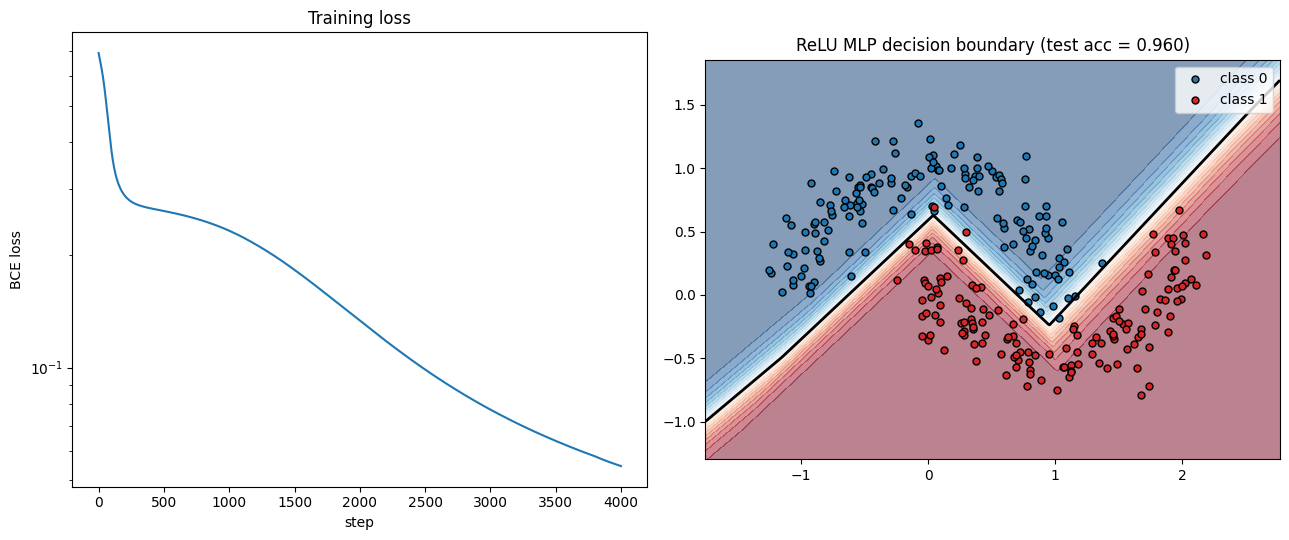

In [ ]:
# --- Plot loss curve and decision boundary side-by-side ---------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: training loss over steps (log y-axis because BCE loss spans orders of magnitude)
axes[0].plot(losses)
axes[0].set_yscale('log')
axes[0].set_xlabel('step'); axes[0].set_ylabel('BCE loss')
axes[0].set_title('Training loss')

# Right: decision boundary plus training data
XX, YY, G = make_grid(X)
with torch.no_grad():
    # Probabilities on the grid. Sigmoid of logits -> P(y=1 | x).
    P_grid = torch.sigmoid(model(torch.tensor(G, dtype=torch.float32))).numpy()
P_grid = P_grid.reshape(XX.shape)

axes[1].contourf(XX, YY, P_grid, levels=20, cmap='RdBu_r', alpha=0.5)
axes[1].contour(XX, YY, P_grid, levels=[0.5], colors='k', linewidths=2)
plot_points(axes[1], X_tr, y_tr)
axes[1].set_title(f'ReLU MLP decision boundary (test acc = {test_acc:.3f})')
axes[1].set_aspect('equal'); axes[1].legend()
plt.tight_layout(); plt.show()

## Part 3 — What the hidden layers are doing: the tessellation

A ReLU network is a **piecewise-affine function of its input.** At any
point $x$, each hidden unit is either on (pre-activation $> 0$) or off
($\leq 0$). The binary vector of on/off states is the **activation
pattern** at $x$. The set of points sharing a single pattern is a
convex polygon — a **cell**. Inside a cell every ReLU is locked, so the
whole network is a single affine map.

The tessellation of input space by these cells is a property of the
*trained weights*, not of the data. We'll extract it by evaluating every
pre-activation on a dense grid.


### Checkpoint 3.1 — one neuron

A single first-layer unit has weight $w \in \mathbb{R}^2$ and bias $b$.
Its zero-set $\{x : w^\top x + b = 0\}$ is a straight line: perpendicular
to $w$, offset $-b/\|w\|$ from the origin along $w$.


In [ ]:
# Pull the first-layer weight matrix and bias out of the trained model.
W1 = ...
b1 = ...
print(f'W1 shape: {W1.shape},  b1 shape: {b1.shape}')

unit_idx = 0
w = W1[unit_idx]
b = b1[unit_idx]

XX, YY, G = make_grid(X)
# For each grid point, compute sign of pre-activation to shade the half-planes.
Z = ....
on_mask = (Z > 0).astype(int).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(7, 7))
# Light shading to show the two half-planes:
ax.contourf(XX, YY, on_mask, levels=[-0.5, 0.5, 1.5],
            colors=['#ffcccc', '#ccddff'], alpha=0.6)
# The line itself:
x0_line = np.array([XX.min(), XX.max()])
x1_line = -(w[0] * x0_line + b) / w[1]
ax.plot(x0_line, x1_line, 'k-', lw=2, label=f'unit {unit_idx}: $w^\top x + b = 0$')
plot_points(ax, X_tr, y_tr)
ax.set_xlim(XX.min(), XX.max()); ax.set_ylim(YY.min(), YY.max())
ax.set_title(f'Checkpoint 3.1 — one neuron (unit {unit_idx})')
ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

### Checkpoint 3.2 — two neurons, four patterns

Pick a second unit. Together the two lines split the plane into up to
four regions, one per combination of on/off states: (on, on),
(on, off), (off, on), (off, off).


In [ ]:
# Pick two distinct first-layer units.
unit_a, unit_b = 0, 1

# Evaluate both pre-activations on the grid.
z_a =
z_b =

# Turn each pre-activation into a 0/1 indicator, then combine the pair
# into an integer in {0, 1, 2, 3} labeling the four patterns.
#   bit 0: unit_a is on    bit 1: unit_b is on
pattern_id =
pattern_id = pattern_id.reshape(XX.shape)

# A 4-color map keyed to those integer patterns.
four_colors = ListedColormap(['#ffcccc', '#ccddff', '#ffddcc', '#ccffcc'])

fig, ax = plt.subplots(figsize=(7, 7))
ax.pcolormesh(XX, YY, pattern_id, cmap=four_colors, shading='auto', alpha=0.6)

# Overlay both boundary lines:
for u, label, style in [(unit_a, f'unit {unit_a}', 'k-'),
                        (unit_b, f'unit {unit_b}', 'k--')]:
    w_u, b_u = W1[u], b1[u]
    xs = np.array([XX.min(), XX.max()])
    ys = -(w_u[0] * xs + b_u) / w_u[1]
    ax.plot(xs, ys, style, lw=2, label=label)

plot_points(ax, X_tr, y_tr)
ax.set_xlim(XX.min(), XX.max()); ax.set_ylim(YY.min(), YY.max())
ax.set_title('Checkpoint 3.2 — two neurons, four regions')
ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

### Checkpoint 3.3 — all units


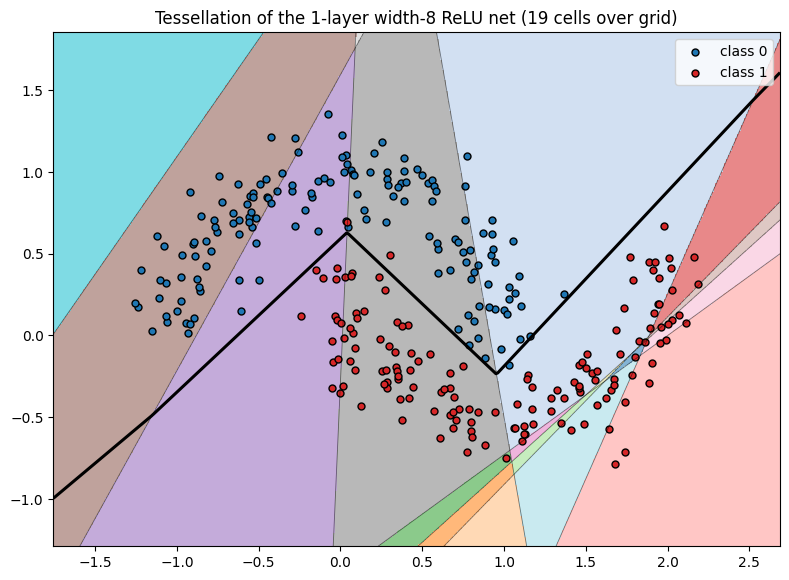

Number of cells realized over the plot region: 19


In [ ]:
def compute_tessellation(model, grid_points):
    """
    Return (pattern_matrix, codes) for a grid.

    pattern_matrix has shape (N, total_hidden_units). Each row stores the
    binary activation pattern at that grid point. `codes` is a flat (N,)
    array of integer hashes of those patterns — two points have the same
    code iff they share the same activation pattern across all hidden units.
    """
    with torch.no_grad():
        # TODO:
        # Convert grid_points to a torch tensor of dtype float32
        t = ...

        # TODO:
        # Run the model with return_preacts=True
        # This should return (_, preacts)
        _, preacts = ...

        # TODO:
        # For each hidden layer pre-activation z in preacts:
        #   1. threshold with (z > 0)
        #   2. convert to int
        # Then concatenate all hidden-layer patterns along dim=1
        pat = ...

        # TODO:
        # Convert pat to a NumPy array
        pat = ...

    # TODO:
    # Hash each binary pattern as a binary number.
    # Hint:
    #   np.arange(pat.shape[1]) gives positions 0,1,2,...
    #   1 << positions gives powers of 2
    #   matrix-vector multiplication combines each row into one integer code
    codes = pat @ (1 << np.arange(...))

    return pat, codes


def plot_tessellation(ax, model, X_overlay, y_overlay, pad=0.5, n=400,
                      show_lines=True, show_boundary=True, rng_seed=42):
    """
    Plot the tessellation induced by `model` on a rectangular grid.

    Each cell gets a random color. Optionally overlay:
      - first-layer zero-sets
      - decision boundary
    """
    # TODO:
    # Create the plotting grid
    # Hint: make_grid(X_overlay, pad=pad, n=n) returns XX, YY, G
    XX, YY, G = ...

    # TODO:
    # Compute tessellation codes on the grid
    _, codes = ...

    # Random color per unique code
    uniq = np.unique(codes)
    rng = np.random.default_rng(rng_seed)

    # TODO:
    # Randomly permute the indices 0, ..., len(uniq)-1
    perm = ...

    # TODO:
    # Build a dictionary mapping each unique code to a color index
    idx_for_code = ...

    # TODO:
    # Replace each code by its assigned color index
    # Then reshape to the grid shape XX.shape
    color_idx = ...

    # TODO:
    # Draw the colored tessellation with pcolormesh
    # Suggested: cmap='tab20', shading='auto', alpha=0.55
    ax.pcolormesh(...)

    if show_lines:
        # Draw first-layer zero-sets (straight lines in input space)

        # TODO:
        # Extract first-layer weights and biases from model.linears[0]
        W1_ = ...
        b1_ = ...

        xs = np.array([XX.min(), XX.max()])

        for i in range(W1_.shape[0]):
            # TODO:
            # Get the i-th weight vector and bias
            w_i = ...
            b_i = ...

            if abs(w_i[1]) > 1e-8:
                # TODO:
                # Compute the line:
                # y = -(w0 * x + b) / w1
                ys = ...

                # TODO:
                # Plot the line
                ax.plot(...)

    if show_boundary:
        # Draw decision boundary as the logit 0-contour

        with torch.no_grad():
            # TODO:
            # Evaluate the model on the grid G
            logits_grid = ...

        # TODO:
        # Reshape logits back to grid shape
        L = ...

        # TODO:
        # Draw the contour corresponding to logit = 0
        ax.contour(...)

    # TODO:
    # Plot the original data points
    plot_points(...)

    # TODO:
    # Set axis limits to match the grid
    ax.set_xlim(...)
    ax.set_ylim(...)

    # TODO:
    # Use equal aspect ratio
    ax.set_aspect(...)

    # TODO:
    # Return the number of unique tessellation cells
    return ...

# --- render for our trained 1-layer-8 model ---------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
n_cells = plot_tessellation(ax, model, X_tr, y_tr,
                            show_lines=True, show_boundary=True)
ax.set_title(f'Tessellation of the 1-layer width-8 ReLU net '
             f'({n_cells} cells over grid)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

print(f'Number of cells realized over the plot region: {n_cells}')

### Checkpoint 3.5 — the Jacobian inside a cell




In [ ]:


def analytical_jacobian_relu_1layer(model, x_np):
    '''Compute the within-cell Jacobian J = W2 D W1 at point x for a one-
    hidden-layer ReLU MLP. Returns (J, D_diag_as_ints).'''
   ....
    return J, D_diag.astype(int)


def autograd_jacobian(model, x_np):
    '''Let autograd compute df/dx at a single point, bypassing the manual
    derivation. We use this as ground truth to verify the analytical formula.'''
  ...
    return grad.numpy().reshape(1, -1)


# --- Pick a cell with several training points inside it ---------------------
pat_tr, codes_tr = compute_tessellation(model, X_tr)
# Find the code (= cell id) that contains the most training points.
vals, counts = ....
best_cell = vals[np.argmax(counts)]
in_cell_mask = codes_tr == best_cell
pts_in_cell  = X_tr[in_cell_mask]
print(f'Working with the most-populated cell (code {best_cell}): '
      f'{in_cell_mask.sum()} training points inside.')

# Take two training points from the same cell.
x_a = pts_in_cell[0]
x_b = pts_in_cell[1]

# And one training point from any other cell.
other_codes = [c for c in vals if c != best_cell]
x_c = X_tr[np.argmax(codes_tr == other_codes[0])]

# Sanity-check: pattern(a) == pattern(b) != pattern(c).
p_a = activation_pattern_at(model, x_a) # Implement this function yourself
p_b = activation_pattern_at(model, x_b)
p_c = activation_pattern_at(model, x_c)
print(f'pattern(x_a) = {p_a}')
print(f'pattern(x_b) = {p_b}  (should equal pattern(x_a))')
print(f'pattern(x_c) = {p_c}  (should differ)')
assert np.array_equal(p_a, p_b), 'x_a and x_b must share an activation pattern'
assert not np.array_equal(p_a, p_c), 'x_c must be in a different cell'

In [ ]:
# --- Analytical vs autograd at x_a, x_b, x_c -------------------------------
J_ana_a, D_a = ...
J_ana_b, D_b = ...
J_ana_c, D_c = ...
J_auto_a = ...
J_auto_b = ...
J_auto_c = ...

def fmt(J):
    return np.array2string(J, precision=3, suppress_small=True)

print('Within-cell (points x_a and x_b, same activation pattern):')
print(f'  D (shared)         = {D_a}')
print(f'  J_analytical(x_a)  = {J_ana_a}')
print(f'  J_autograd  (x_a)  = {J_auto_a}')
print(f'  max |ana - auto|   = {np.max(np.abs(J_ana_a - J_auto_a)):.2e}')
print(f'  J_analytical(x_b)  = {J_ana_b}')
print(f'  J_analytical(x_a) == J_analytical(x_b) ? '
      f'{np.allclose(J_ana_a, J_ana_b)}')

print('\nAcross-cell (point x_c, different pattern):')
print(f'  D (at x_c)         = {D_c}')
print(f'  J_analytical(x_c)  = {J_ana_c}')
print(f'  J_autograd  (x_c)  = {J_auto_c}')
print(f'  max |ana - auto|   = {np.max(np.abs(J_ana_c - J_auto_c)):.2e}')

## Part 4 — Changing the activation

Swap ReLU for tanh.


In [ ]:
# Seed before construction so the tanh net uses the same init as the ReLU one.
torch.manual_seed(0)
tanh_model = ....
tanh_losses = ...

tanh_train = accuracy(tanh_model, Xtr, ytr)
tanh_test  = accuracy(tanh_model, Xte, yte)
print(f'tanh MLP: train = {tanh_train:.4f}, test = {tanh_test:.4f}')

tanh MLP: train = 0.9900, test = 0.9600


In [ ]:
# =========================================================
# tanh network
# Goal:
#   - evaluate the tanh model on a grid
#   - turn logits into probabilities
#   - draw a smooth background + decision boundary
#   - draw first-layer pre-activation zero-lines
# =========================================================


In [ ]:
# --- Jacobian for the tanh net ---------------------------------------------
# Analytical form: J = W2 @ diag(tanh'(z)) @ W1, where z = W1 x + b1.
# tanh'(z) = 1 - tanh(z)^2.
def analytical_jacobian_tanh_1layer(model, x_np):
      ....
      return (W2 * dphi) @ W1

# Evaluate at three different points to show the Jacobian genuinely varies.
test_points = [X_tr[0], X_tr[50], X_tr[100]]
print(f'{"point":<8}  {"J (analytical)":<28}  {"J (autograd)":<28}  {"|diff|":<10}')
for i, x_pt in enumerate(test_points):
    J_ana  = analytical_jacobian_tanh_1layer(tanh_model, x_pt)
    J_auto = autograd_jacobian(tanh_model, x_pt)
    err = np.max(np.abs(J_ana - J_auto))
    print(f'x_tr[{i*50:>3}]  {np.array2string(J_ana,  precision=3):<28}  '
          f'{np.array2string(J_auto, precision=3):<28}  {err:.2e}')

## Part 5 — Width, depth, capacity

Three architectures, same dataset, same optimizer:

| tag      | architecture    | #params | seed |
|----------|-----------------|---------|------|
| `w3-1L`  | 1 layer, width 3 | 13     | 0    |
| `w12-1L` | 1 layer, width 12 | 49     | 0    |
| `w6-2L`  | 2 layers, 6+6   | 67      | 3    |



In [ ]:
# Part 5 configurations. We fix seeds per-architecture so the lesson
# reproduces every time the notebook is re-run.
configs = [
    ('w3-1L',  (3,),   0, 6000, 0.1),
    ('w12-1L', (12,),  0, 4000, 0.1),
    ('w6-2L',  (6, 6), 3, 6000, 0.1),
]

part5_models = {}
for tag, hidden, seed, steps, lr_val in configs:
    .....
    print(f'{tag:<8} hidden={str(hidden):<10} seed={seed}  '
          f'params={n_params:>3}  cells={n_cells:>3}  '
          f'train={accuracy(m,Xtr,ytr):.3f}  test={accuracy(m,Xte,yte):.3f}')

w3-1L    hidden=(3,)       seed=0  params= 13  cells=  7  train=0.867  test=0.890
w12-1L   hidden=(12,)      seed=0  params= 49  cells= 51  train=0.993  test=0.960
w6-2L    hidden=(6, 6)     seed=3  params= 67  cells= 80  train=0.993  test=0.960


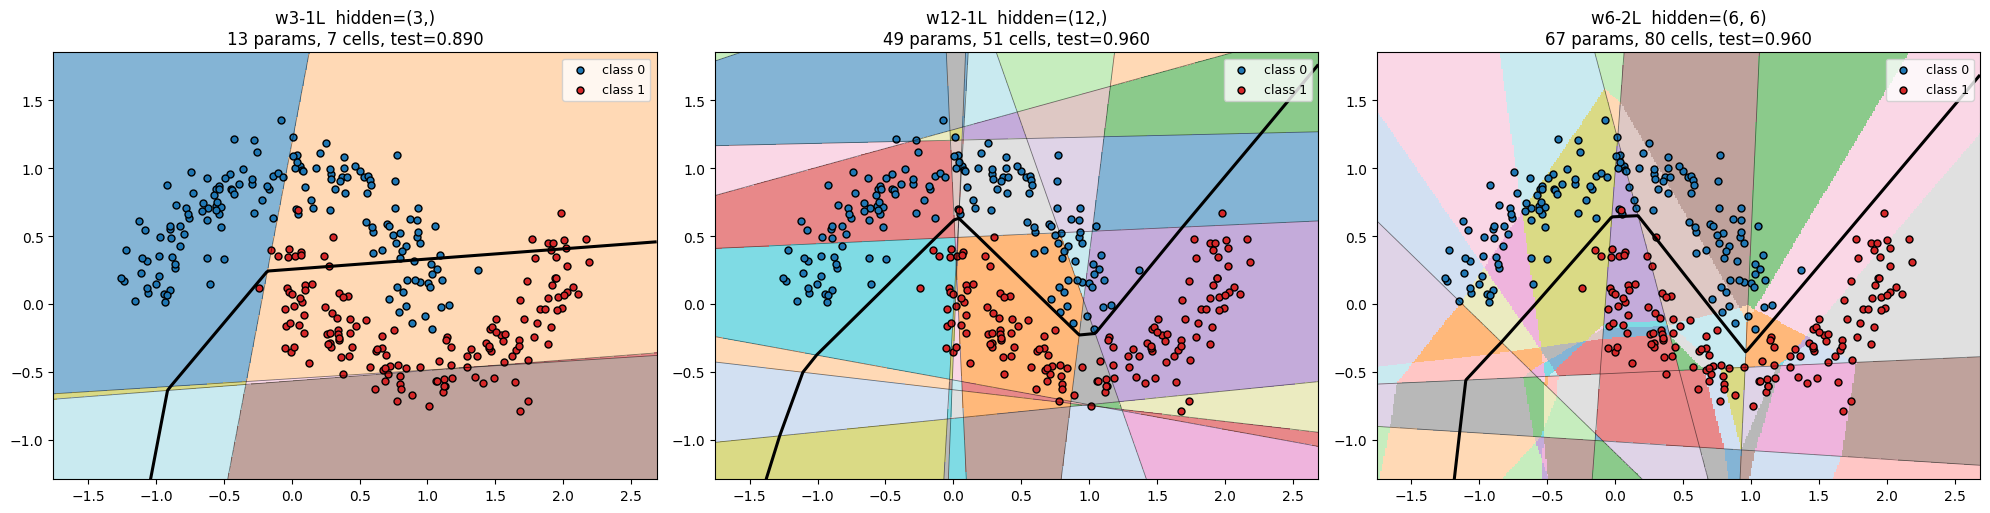

In [ ]:
# --- Side-by-side tessellations for all three architectures -----------------
....